# Customer Churn Prediction & Retention Analytics

## Customer Analytics | Predictive Analytics | Business Intelligence

Portfolio project for **Business Analytics, Analytics Consulting, Customer Analytics, and Data Analytics** roles.

---

**Research Question:** How can customer behavior and business data be used to predict customer churn and generate actionable retention strategies?

**Core Narrative:** Data → Analysis → Insight → Business Recommendation

**Data Source:** Bank Customer Churn Dataset comprising **10,000 customer records** with demographic, behavioral, and financial information. The dataset includes customer characteristics such as age, geography, tenure, account balance, product usage, credit score, satisfaction score, complaint history, and loyalty points. The target variable, **Exited**, represents customer churn and serves as the basis for the predictive and business analyses performed in this notebook.

---

# Problem Statement

Customer churn is a significant challenge for subscription-based and service-oriented businesses, as losing existing customers directly impacts recurring revenue, customer lifetime value, and long-term profitability. Since acquiring new customers is considerably more expensive than retaining existing ones, organizations require a structured approach to identify customers at risk of leaving and design targeted retention strategies.

This project develops a customer churn analytics framework to analyze customer behavior, identify key churn drivers, build predictive models, and generate business recommendations that support data-driven customer retention decisions.

**Business Objective:** Identify high-risk customer segments, understand the factors influencing customer attrition, estimate potential revenue at risk, and provide actionable recommendations that improve customer retention and long-term business performance.

---

# Business Context

The analysis is designed from a **Business Analytics and Analytics Consulting** perspective rather than purely as a machine learning exercise. It addresses questions such as:

- Which customer segments exhibit the highest churn risk?
- Which demographic and behavioral factors contribute most to customer attrition?
- How do tenure, product usage, and payment behavior influence customer retention?
- Which customers should be prioritized for retention initiatives?
- How can predictive analytics support more effective customer retention strategies?

The notebook combines **Exploratory Data Analysis (EDA), SQL-based business analysis, statistical techniques, predictive modelling, and business recommendations** to translate analytical findings into practical customer retention strategies.

---



# 01 Data Understanding

Customer Churn Prediction & Retention Analytics

This notebook follows the consulting analytics flow: data, analysis, insight, and recommendation. Run from the repository root.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

raw = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
raw.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [38]:
raw.shape, raw.dtypes

((10000, 18),
 RowNumber               int64
 CustomerId              int64
 Surname                object
 CreditScore             int64
 Geography              object
 Gender                 object
 Age                     int64
 Tenure                  int64
 Balance               float64
 NumOfProducts           int64
 HasCrCard               int64
 IsActiveMember          int64
 EstimatedSalary       float64
 Exited                  int64
 Complain                int64
 Satisfaction Score      int64
 Card Type              object
 Point Earned            int64
 dtype: object)

In [39]:
raw.isna().sum().sort_values(ascending=False)

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [40]:
raw.duplicated().sum()

np.int64(0)

In [41]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


## Churn Distribution

The dataset contains 10,000 customers and an observed churn rate of 20.4%. This creates a realistic class imbalance problem for retention analytics.

In [42]:
raw['Exited'].value_counts(normalize=True).rename('share')

Exited
0    0.7962
1    0.2038
Name: share, dtype: float64

# 02 Data Cleaning

Customer Churn Prediction & Retention Analytics

Documents the feature engineering used in the processed dataset.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

df = pd.read_csv('../data/processed/customer_churn_processed.csv')
df.head()

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,...,annual_value_proxy,monthly_value_proxy,monthly_spend_category,customer_lifetime_value,customer_value_segment,revenue_at_risk,high_risk_customer_flag,active_status,credit_card_status,product_segment
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,858.74,71.56,Low,1717.48,Bronze,858.74,1,Active,Has Credit Card,1 product(s)
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,2586.87,215.57,Medium,2586.87,Bronze,0.00,1,Active,No Credit Card,1 product(s)
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,4311.37,359.28,Very High,34490.96,Platinum,4311.37,1,Inactive,Has Credit Card,3+ products
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,884.13,73.68,Low,884.13,Bronze,0.00,0,Inactive,No Credit Card,2 product(s)
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,3238.14,269.84,High,6476.28,Silver,0.00,0,Active,Has Credit Card,1 product(s)


In [44]:
df.isna().sum().sort_values(ascending=False).head(20)

rownumber             0
customerid            0
surname               0
creditscore           0
geography             0
gender                0
age                   0
tenure                0
balance               0
numofproducts         0
hascrcard             0
isactivemember        0
estimatedsalary       0
exited                0
complain              0
satisfaction_score    0
card_type             0
point_earned          0
payment_proxy         0
churn                 0
dtype: int64

In [45]:
df[['age_group','tenure_group','monthly_spend_category','customer_value_segment','annual_value_proxy','customer_lifetime_value','revenue_at_risk','high_risk_customer_flag']].head()

,age_group,tenure_group,monthly_spend_category,customer_value_segment,annual_value_proxy,customer_lifetime_value,revenue_at_risk,high_risk_customer_flag
0,41-50,0-2 years,Low,Bronze,858.74,1717.48,858.74,1
1,41-50,0-2 years,Medium,Bronze,2586.87,2586.87,0.00,1
2,41-50,6-8 years,Very High,Platinum,4311.37,34490.96,4311.37,1
3,31-40,0-2 years,Low,Bronze,884.13,884.13,0.00,0
4,41-50,0-2 years,High,Silver,3238.14,6476.28,0.00,0


The bank dataset does not contain direct monthly spend. The project therefore defines a documented annual relationship value proxy from balance, estimated salary, product count, and loyalty points.

# 03 Exploratory Data Analysis

Customer Churn Prediction & Retention Analytics

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

df = pd.read_csv('../data/processed/customer_churn_processed.csv')

In [47]:
pd.crosstab(df['geography'], df['churn'], normalize='index')

churn,0,1
geography,,
France,0.838253,0.161747
Germany,0.675568,0.324432
Spain,0.833266,0.166734


### Observation
Germany has the highest churn rate in the portfolio.

### Business Interpretation
Regional service experience or product fit may be materially different.

### Recommendation
Prioritize Germany-specific save offers and root-cause interviews.

Text(0.5, 1.0, 'Churn Rate by Age Group')

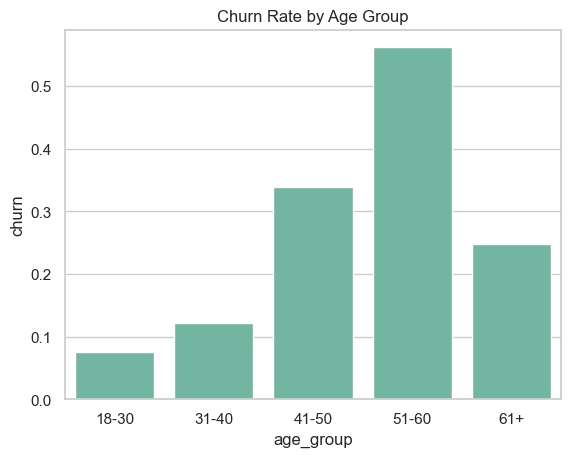

In [48]:
sns.barplot(data=df.groupby('age_group', observed=False)['churn'].mean().reset_index(), x='age_group', y='churn')
plt.title('Churn Rate by Age Group')

### Observation
Middle-aged and older groups show elevated attrition.

### Business Interpretation
Financial needs may become more complex with age, making service gaps more visible.

### Recommendation
Create proactive relationship reviews for customers above the high-risk age threshold.

Text(0.5, 1.0, 'Correlation Matrix')

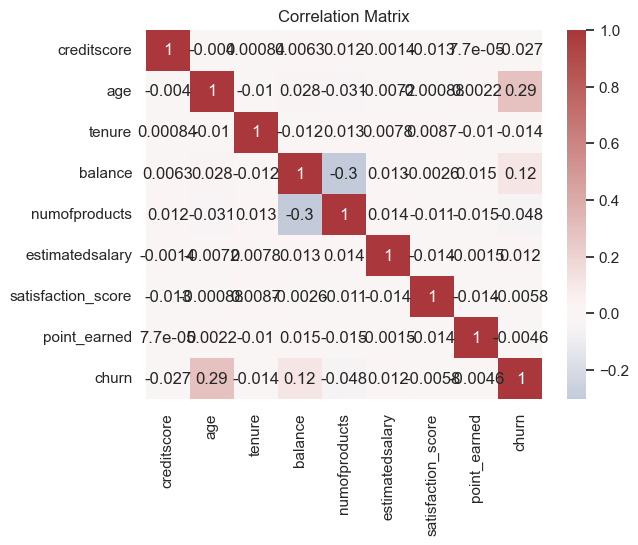

In [49]:
sns.heatmap(df[['creditscore','age','tenure','balance','numofproducts','estimatedsalary','satisfaction_score','point_earned','churn']].corr(), annot=True, cmap='vlag', center=0)
plt.title('Correlation Matrix')

# 04 SQL Analysis

Customer Churn Prediction & Retention Analytics

This notebook uses SQLite to demonstrate the SQL logic from the `sql/` folder on the processed dataset.

In [50]:
import pandas as pd, sqlite3
conn = sqlite3.connect(':memory:')
df = pd.read_csv('../data/processed/customer_churn_processed.csv')
df.to_sql('customer_churn', conn, index=False, if_exists='replace')

10000

In [51]:
pd.read_sql_query("""
SELECT gender, COUNT(*) AS customers, SUM(churn) AS churned, ROUND(100.0 * AVG(churn), 2) AS churn_rate_pct
FROM customer_churn
GROUP BY gender
ORDER BY churn_rate_pct DESC
""", conn)

,gender,customers,churned,churn_rate_pct
0,Female,4543,1139,25.07
1,Male,5457,899,16.47


In [52]:
pd.read_sql_query("""
WITH segment_loss AS (
 SELECT customer_value_segment, SUM(revenue_at_risk) AS value_at_risk
 FROM customer_churn
 GROUP BY customer_value_segment
)
SELECT *, ROUND(100.0 * value_at_risk / SUM(value_at_risk) OVER (), 2) AS share_of_value_at_risk_pct
FROM segment_loss
ORDER BY value_at_risk DESC
""", conn)

,customer_value_segment,value_at_risk,share_of_value_at_risk_pct
0,Platinum,2229843.39,38.95
1,Gold,1631559.03,28.50
2,Bronze,958145.76,16.74
3,Silver,905232.89,15.81


# 05 Statistical Analysis

Customer Churn Prediction & Retention Analytics

Hypothesis tests quantify which observed differences are statistically meaningful.

In [53]:
import pandas as pd
tests = pd.read_csv('../data/processed/statistical_tests.csv')
tests

,test,statistic,p_value,significant_at_5pct
0,T-test: Tenure differs by churn,-1.350008,1.771113e-01,False
1,T-test: Monthly value proxy differs by churn,12.053391,9.036344e-33,True
2,T-test: Age differs by churn,30.420282,4.399452e-179,True
3,Chi-square: Payment/Card type associated with ...,5.053223,1.679411e-01,False
4,Chi-square: Geography associated with churn,300.626401,5.245736e-66,True
5,Chi-square: Gender associated with churn,112.396554,2.925368e-26,True
6,Chi-square: Age group associated with churn,1288.205605,1.200427e-277,True


Interpret tests with business judgment: statistical significance shows association, not automatic causality.

# 06 Machine Learning

Customer Churn Prediction & Retention Analytics

The modeling workflow compares Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM. The primary model excludes complaint and churn-derived fields to reduce leakage risk.

In [54]:
import pandas as pd
metrics = pd.read_csv('../data/processed/model_metrics.csv')
metrics

,model,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,0.8700,0.826241,0.457760,0.589128,0.870088
1,LightGBM,0.8228,0.551242,0.697446,0.615785,0.868362
2,Random Forest,0.8296,0.563748,0.721022,0.632759,0.867412
3,Logistic Regression,0.7728,0.463980,0.746562,0.572289,0.850830
4,Decision Tree,0.7836,0.479221,0.724951,0.577013,0.835867


In [55]:
pd.read_csv('../data/processed/feature_importance.csv').head(15)

,feature,importance
0,age,0.179470
1,product_segment_2 product(s),0.124476
2,product_segment_1 product(s),0.069527
3,numofproducts,0.067599
4,product_segment_3+ products,0.047760
5,age_group_51-60,0.038726
6,annual_value_proxy,0.038262
7,monthly_value_proxy,0.036771
8,balance,0.030857
9,geography_Germany,0.029599


The tuned Random Forest achieved ROC-AUC of 0.868, giving a practical retention-ranking model for prioritizing outreach.